# Cartola Pro: o que diferencia quem assina

**Pergunta de negócio:** quais comportamentos de consumo no ge.globo.com, durante as Olimpíadas, estão associados à assinatura do Cartola Pro?

**Recorte principal:** usuários que já jogam Cartola (Free + Pro). A pergunta de produto é *converter Free em Pro*, e é aí que existe base de comparação.

**Natureza da análise:** exploratória e correlacional. Os padrões mostram associação, não causalidade (ex.: o Pro pode acessar mais *porque* assina).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

DATA_PATH = "../data/base_desafio_cartola.csv"
COR_PRO, COR_FREE, COR_NEUTRA = "#f240a0", "#ae46e2", "#bdb7cc"
DISPOSITIVO = {"m_only": "Celular", "pc_only": "Computador", "pc_e_m": "Ambos"}
COR_DISPOSITIVO = {"Celular": COR_NEUTRA, "Computador": COR_FREE, "Ambos": COR_PRO}

## 1. Carga e qualidade dos dados

In [2]:
# 'NA' vem como texto no arquivo: lemos como string para tratar explicitamente
df_raw = pd.read_csv(DATA_PATH, keep_default_na=False, na_values=[""])
print(df_raw.shape)
print("usuários duplicados:", df_raw["user"].duplicated().sum())

(df_raw.astype(str).eq("NA").mean().loc[lambda s: s > 0]
       .sort_values(ascending=False).to_frame("% 'NA'"))

(50689, 26)
usuários duplicados: 0


,% 'NA'
uf,0.575
sexo,0.557
idade,0.554
cartola_status,0.360


In [3]:
df_raw["cartola_status"].value_counts(dropna=False).to_frame("usuários")

,usuários
cartola_status,
Cartola Free,29019
NA,18257
Não Cartola,2336
Cartola Pro,1077


**Pontos de qualidade a reportar:**
- `cartola_status` = NA em ~36% da base: status desconhecido, fica **fora** do recorte (não dá para assumir que é "Não Cartola").
- Demografia (`sexo`, `uf`, `idade`) ausente em ~55%; ausência praticamente total entre os "Não Cartola", o que sugere que vem do cadastro/login. A ausência em si é um sinal (ver seção 6).
- `idade` tem valores impossíveis (negativos, > 100): tratados como ausentes.

## 2. Limpeza e variáveis derivadas

In [4]:
EDITORIAS_FUTEBOL = ["futebol", "futebol_intenacional", "blog_cartola"]
EDITORIAS_OLIMPICAS = ["futebol_olimpico", "atletismo", "ginastica", "judo", "natacao", "basquete",
                       "handebol", "volei", "tenis", "canoagem", "saltos_ornamentais", "home_olimpiadas"]
EDITORIAS = EDITORIAS_FUTEBOL + EDITORIAS_OLIMPICAS + ["home"]

df = df_raw.replace("NA", np.nan).copy()
df["idade"] = pd.to_numeric(df["idade"], errors="coerce")
df.loc[~df["idade"].between(10, 90), "idade"] = np.nan

# Engajamento
df["min_total"] = df["tempo_total"] / 60
df["pviews_por_visita"] = df["pviews"] / df["visitas"]
df["min_por_dia"] = df["min_total"] / df["dias"]
df["faixa_dias"] = pd.cut(df["dias"], [0, 3, 7, 14, 21, 31],
                          labels=["1-3", "4-7", "8-14", "15-21", "22-31"])

# Conteúdo
df["share_futebol"] = df[EDITORIAS_FUTEBOL].sum(axis=1) / df["tempo_total"]
df["share_olimpico"] = df[EDITORIAS_OLIMPICAS].sum(axis=1) / df["tempo_total"]
df["n_modalidades_olimpicas"] = (df[EDITORIAS_OLIMPICAS] > 0).sum(axis=1)
df["le_blog_cartola"] = df["blog_cartola"] > 0

# Perfil
df["faixa_idade"] = pd.cut(df["idade"], [0, 24, 34, 44, 90], labels=["até 24", "25-34", "35-44", "45+"])
df["demografia_conhecida"] = df["sexo"].notna()

# Recorte de análise: jogadores de Cartola com status conhecido
jog = df[df["cartola_status"].isin(["Cartola Free", "Cartola Pro"])].copy()
jog["pro"] = (jog["cartola_status"] == "Cartola Pro").astype(int)
TAXA_BASE = jog["pro"].mean()
print(f"Jogadores: {len(jog):,} | Pro: {jog['pro'].sum():,} | taxa Pro base: {TAXA_BASE:.1%}")

Jogadores: 30,096 | Pro: 1,077 | taxa Pro base: 3.6%


In [5]:
def taxa_pro(data, col):
    """Taxa de Pro por grupo, tamanho do grupo e lift vs. a taxa base."""
    t = data.groupby(col, observed=True)["pro"].agg(taxa_pro="mean", usuarios="size")
    t["lift"] = t["taxa_pro"] / TAXA_BASE
    return t

def barra_taxa(t, titulo, ax=None, cores=COR_PRO):
    ax = ax or plt.gca()
    ax.bar(t.index.astype(str), t["taxa_pro"] * 100, color=cores)
    ax.axhline(TAXA_BASE * 100, ls="--", color="grey", lw=1)
    ax.text(len(t) - 0.5, TAXA_BASE * 100, " média", va="bottom", ha="right", color="grey", fontsize=8)
    for i, v in enumerate(t["taxa_pro"] * 100):
        ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title(titulo, loc="left", fontsize=11)
    ax.set_ylabel("% Pro")
    return ax

## 3. Pro vs Free: o retrato geral

In [6]:
metricas = ["dias", "visitas", "pviews", "min_total", "pviews_por_visita", "min_por_dia", "idade"]
resumo = jog.groupby("cartola_status")[metricas].median().T
resumo["Pro / Free"] = resumo["Cartola Pro"] / resumo["Cartola Free"]

# Mann-Whitney: distribuições não normais e muito assimétricas
resumo["p-valor"] = [stats.mannwhitneyu(jog.loc[jog.pro == 1, m].dropna(),
                                        jog.loc[jog.pro == 0, m].dropna()).pvalue for m in metricas]
resumo  # medianas

cartola_status,Cartola Free,Cartola Pro,Pro / Free,p-valor
dias,6.000,14.000,2.333,0.000
visitas,8.000,23.000,2.875,0.000
pviews,18.000,71.000,3.944,0.000
min_total,28.963,153.119,5.287,0.000
pviews_por_visita,2.000,2.871,1.435,0.000
min_por_dia,4.440,11.260,2.536,0.000
idade,26.000,29.000,1.115,0.000


> Com ~30 mil usuários quase tudo dá p-valor baixo. Na apresentação, falar do **tamanho da diferença** (razão de medianas, lift), não do p-valor.

## 4. Engajamento: frequência é o sinal mais forte

,taxa_pro,usuarios,lift
faixa_dias,,,
1-3,0.014,10202,0.397
4-7,0.030,5751,0.831
8-14,0.041,5631,1.141
15-21,0.054,4039,1.515
22-31,0.070,4473,1.949


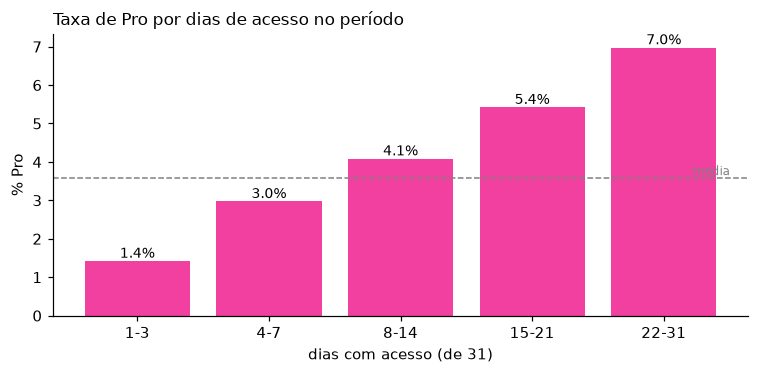

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
t_dias = taxa_pro(jog, "faixa_dias")
barra_taxa(t_dias, "Taxa de Pro por dias de acesso no período", ax)
ax.set_xlabel("dias com acesso (de 31)")
plt.tight_layout(); plt.savefig("../outputs/figures/fig_dias.png", bbox_inches="tight")
t_dias

## 5. Dispositivo: quem usa PC e celular assina mais

,taxa_pro,usuarios,lift
device,,,
Celular,0.017,11141,0.482
Computador,0.032,10401,0.881
Ambos,0.065,8554,1.820


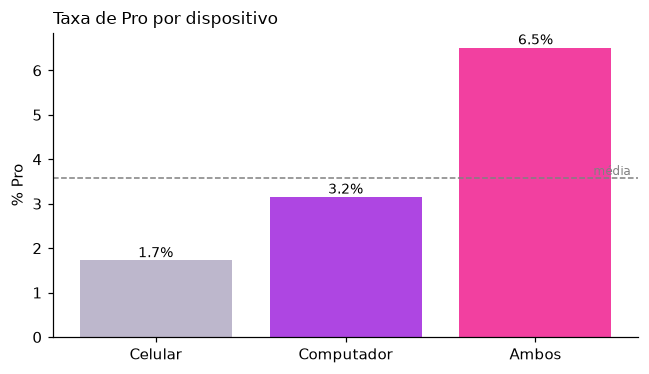

In [8]:
t_dev = taxa_pro(jog, "device").rename(index=DISPOSITIVO).sort_values("taxa_pro")
fig, ax = plt.subplots(figsize=(6, 3.5))
barra_taxa(t_dev, "Taxa de Pro por dispositivo", ax, cores=[COR_DISPOSITIVO[d] for d in t_dev.index])
plt.tight_layout(); plt.savefig("../outputs/figures/fig_device.png", bbox_inches="tight")
t_dev

Controle: o efeito de dispositivo continua quando comparamos usuários com a **mesma** frequência?

device,m_only,pc_e_m,pc_only
faixa_dias,,,
1-3,0.900,2.700,1.800
4-7,2.000,4.900,2.600
8-14,1.900,5.400,4.700
15-21,2.300,7.500,4.900
22-31,4.600,9.100,4.400


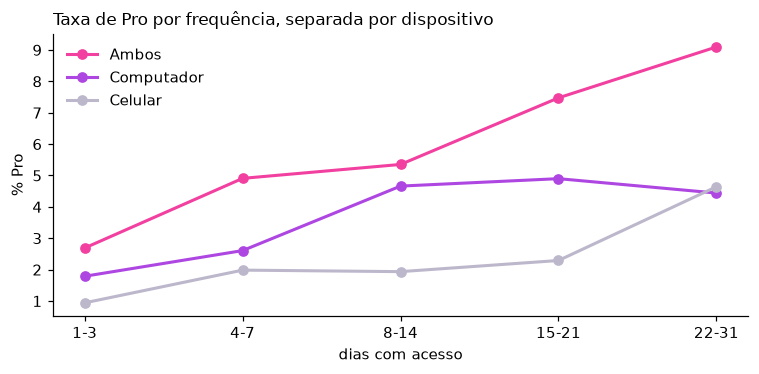

In [9]:
ctrl = jog.pivot_table(index="faixa_dias", columns="device", values="pro", aggfunc="mean", observed=True)
fig, ax = plt.subplots(figsize=(7, 3.5))
for dev in ["pc_e_m", "pc_only", "m_only"]:
    nome = DISPOSITIVO[dev]
    ax.plot(ctrl.index.astype(str), ctrl[dev] * 100, marker="o", label=nome, color=COR_DISPOSITIVO[nome], lw=2)
ax.set_title("Taxa de Pro por frequência, separada por dispositivo", loc="left", fontsize=11)
ax.set_ylabel("% Pro"); ax.set_xlabel("dias com acesso"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig("../outputs/figures/fig_device_ctrl.png", bbox_inches="tight")
(ctrl * 100).round(1)

## 6. Conteúdo consumido

cartola_status,Cartola Free,Cartola Pro,lift
blog_cartola,0.766,0.846,1.104
futebol,0.716,0.877,1.226
home,0.547,0.744,1.361
futebol_intenacional,0.250,0.370,1.476
futebol_olimpico,0.377,0.557,1.477
home_olimpiadas,0.352,0.532,1.513
volei,0.155,0.274,1.763
basquete,0.159,0.282,1.770
ginastica,0.163,0.292,1.790
atletismo,0.190,0.346,1.821


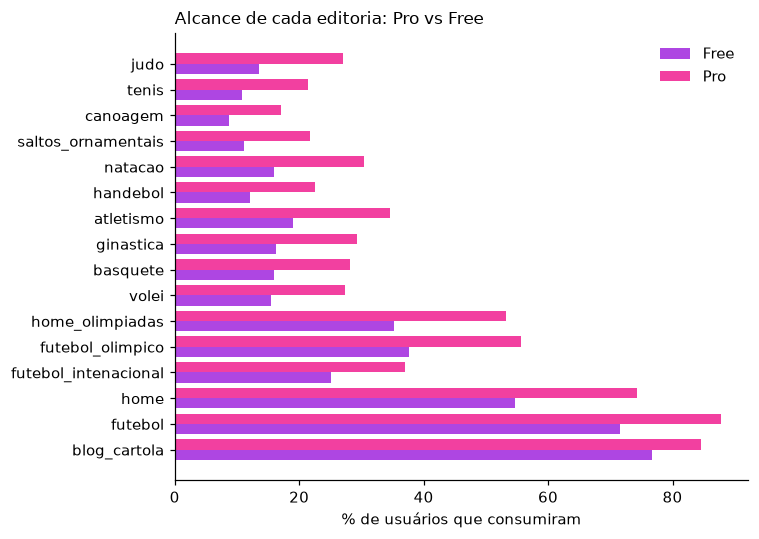

In [10]:
# Penetração: % de usuários do grupo que consumiu cada editoria
pen = jog.groupby("cartola_status")[EDITORIAS].apply(lambda x: (x > 0).mean()).T
pen["lift"] = pen["Cartola Pro"] / pen["Cartola Free"]
pen = pen.sort_values("lift")

fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(pen))
ax.barh(y - 0.2, pen["Cartola Free"] * 100, 0.4, color=COR_FREE, label="Free")
ax.barh(y + 0.2, pen["Cartola Pro"] * 100, 0.4, color=COR_PRO, label="Pro")
ax.set_yticks(y, pen.index); ax.set_xlabel("% de usuários que consumiram")
ax.set_title("Alcance de cada editoria: Pro vs Free", loc="left", fontsize=11); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig("../outputs/figures/fig_editorias.png", bbox_inches="tight")
pen

In [11]:
# Composição do tempo (mix): onde vai o minuto de cada grupo
mix = jog.groupby("cartola_status")[EDITORIAS].sum()
mix = mix.div(mix.sum(axis=1), axis=0).T.sort_values("Cartola Pro", ascending=False)
mix

cartola_status,Cartola Free,Cartola Pro
futebol,0.404,0.419
home,0.200,0.173
blog_cartola,0.116,0.128
futebol_olimpico,0.075,0.067
home_olimpiadas,0.041,0.040
natacao,0.015,0.024
judo,0.018,0.023
basquete,0.018,0.021
atletismo,0.019,0.021
ginastica,0.016,0.019


In [12]:
# Amplitude olímpica vs frequência: o efeito sobrevive ao controle?
jog["amplitude_olimpica"] = pd.cut(jog["n_modalidades_olimpicas"], [-1, 0, 2, 12], labels=["nenhuma", "1-2", "3+"])
display(taxa_pro(jog, "amplitude_olimpica"))
(jog.pivot_table(index="faixa_dias", columns="amplitude_olimpica", values="pro", aggfunc="mean", observed=True) * 100).round(1)

,taxa_pro,usuarios,lift
amplitude_olimpica,,,
nenhuma,0.021,14225,0.599
1-2,0.033,7174,0.915
3+,0.062,8697,1.725


amplitude_olimpica,nenhuma,1-2,3+
faixa_dias,,,
1-3,1.400,1.300,2.900
4-7,2.600,2.700,5.800
8-14,3.300,4.200,4.700
15-21,4.900,5.800,5.400
22-31,5.600,3.700,7.700


In [13]:
taxa_pro(jog, "le_blog_cartola")

,taxa_pro,usuarios,lift
le_blog_cartola,,,
False,0.024,6948,0.668
True,0.039,23148,1.100


## 7. Perfil demográfico (com ressalvas de cobertura)

,taxa_pro,usuarios,lift
sexo,,,
F,0.027,729,0.767
M,0.053,14789,1.495


,taxa_pro,usuarios,lift
uf,,,
Espirito Santo,0.041,368,1.139
Rio de Janeiro,0.042,2343,1.181
Pernambuco,0.043,604,1.203
Minas Gerais,0.045,1884,1.246
Rio Grande do Sul,0.046,928,1.295
Bahia,0.047,847,1.320
Ceara,0.052,344,1.462
Santa Catarina,0.053,585,1.481
Sao Paulo,0.057,5328,1.589


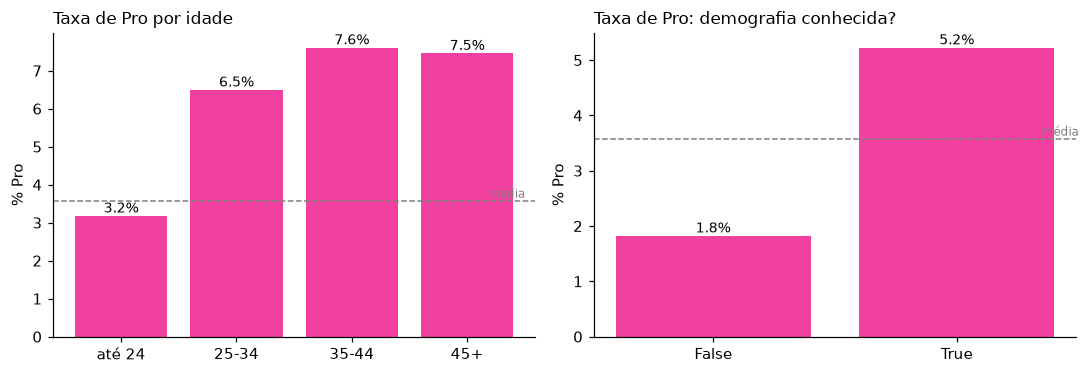

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
barra_taxa(taxa_pro(jog, "faixa_idade"), "Taxa de Pro por idade", axes[0])
barra_taxa(taxa_pro(jog, "demografia_conhecida"), "Taxa de Pro: demografia conhecida?", axes[1])
plt.tight_layout(); plt.savefig("../outputs/figures/fig_demografia.png", bbox_inches="tight")
display(taxa_pro(jog, "sexo"))
taxa_pro(jog, "uf").query("usuarios >= 300").sort_values("taxa_pro")

> Demografia existe para ~metade dos jogadores. Usuários **sem** demografia assinam bem menos, provavelmente porque são menos logados/identificados. Isso é um achado de produto (identificação), mas impede generalizar idade/sexo/UF para toda a base.

## 8. Do achado ao público-alvo: segmentos acionáveis

In [15]:
# Regras simples, explicáveis para produto (sem modelo)
jog["segmento"] = np.select(
    [(jog["dias"] >= 15) & (jog["device"] == "pc_e_m"),
     (jog["dias"] >= 15),
     (jog["dias"] >= 8)],
    ["Fiel multi-device", "Fiel", "Recorrente"],
    default="Ocasional")

seg = jog.groupby("segmento").agg(usuarios=("pro", "size"), pros=("pro", "sum"), taxa_pro=("pro", "mean"))
seg["% da base"] = seg["usuarios"] / seg["usuarios"].sum()
seg["% dos Pro"] = seg["pros"] / seg["pros"].sum()
seg["lift"] = seg["taxa_pro"] / TAXA_BASE
seg.sort_values("taxa_pro", ascending=False)

,usuarios,pros,taxa_pro,% da base,% dos Pro,lift
segmento,,,,,,
Fiel multi-device,4190,352,0.084,0.139,0.327,2.348
Fiel,4322,179,0.041,0.144,0.166,1.157
Recorrente,5631,230,0.041,0.187,0.214,1.141
Ocasional,15953,316,0.020,0.530,0.293,0.554


## 9. Síntese dos achados

1. **Frequência é o principal sinal:** a taxa de Pro vai de 1,4% (1–3 dias de acesso) a 7,0% (22–31 dias).
2. **Uso multi-device importa por si só:** PC + celular converte 6,5% vs. 1,7% só celular, e a diferença se mantém com frequência controlada.
3. **Conteúdo:** o Pro consome mais de todas as editorias. O efeito das modalidades olímpicas é em parte explicado por volume: some entre os usuários frequentes, mas segue ~2x entre os ocasionais (1–3 dias: 2,9% vs. 1,4%).
4. **Perfil:** usuários com demografia preenchida (proxy de identificados) convertem 5,2% vs. 1,8%; 25+ anos convertem ~2x mais que até 24.
5. **Segmento prioritário:** "Fiel multi-device" (15+ dias, PC + celular) = 14% dos jogadores, 33% dos Pro, taxa 8,4% (2,3x a base).

**Limitações:** correlação ≠ causalidade; janela de 1 mês atípica (Olimpíadas); 36% sem status; demografia parcial; não sabemos *quando* o usuário virou Pro (antes ou durante o período).